In [1]:
!nvidia-smi

Mon Aug 25 13:58:44 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   25C    P8             11W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os

HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


## Install dependencies

In [3]:
!pip install -q ultralytics supervision trackers==2.0.2rc0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 4.7 MB/s eta 0:00:00


### Download video + weights

In [ ]:
!wget -q https://raw.githubusercontent.com/droneforge/yolov11n-UAV-finetune/main/yolov11n-UAV-finetune.pt
!wget -q https://raw.githubusercontent.com/droneforge/yolov11n-UAV-finetune/main/anduril_swarm.mp4

In [ ]:
!gunzip -k yolo12l-UAV-finetune.pt.gz

gzip: yolo12l-UAV-finetune.pt.gz: No such file or directory


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

SOURCE_VIDEO_PATH = Path(HOME) / "infer_vids/anduril_swarm.mp4"
SOURCE_VIDEO_PATH_2 = Path(HOME) / "infer_vids/swarm_bg_terrain1/swarm_bg_terrain1.mp4"
SOURCE_WEIGHTS_PATH = Path(HOME) / "yolo12l-UAV-finetune.pt"

In [ ]:
from pathlib import Path

SOURCE_VIDEO_PATH = "/content/drive/MyDrive/NUEVO-SEGUIDOR/yolov11-UAV-finetune-main/yolov11-UAV-finetune-main/synthetic_drone_swarm_sim/infer_vids/anduril_swarm.mp4"
SOURCE_VIDEO_PATH_2 = "/content/drive/MyDrive/NUEVO-SEGUIDOR/yolov11-UAV-finetune-main/yolov11-UAV-finetune-main/synthetic_drone_swarm_sim/infer_vids/swarm_bg_terrain1.mp4"
SOURCE_WEIGHTS_PATH = "/content/drive/MyDrive/NUEVO-SEGUIDOR/yolov11-UAV-finetune-main/yolov11-UAV-finetune-main/yolov11n-UAV-finetune.pt"

In [9]:
from pathlib import Path

SOURCE_VIDEO_PATH = "/content/drive/MyDrive/Rosas-2025/05-07/redimensionamiento-0.5-6/GX011352.MP4"
SOURCE_VIDEO_PATH_2 = "/content/drive/MyDrive/Rosas-2025/05-07/redimensionamiento-0.5-6/GX011352.MP4"
SOURCE_WEIGHTS_PATH = "/content/drive/MyDrive/Proyecto Rosas - 2/modelos/Y11/mondial-Y11-90.pt"

## Load model

In [10]:
import supervision as sv
from ultralytics import YOLO

MODEL = YOLO(SOURCE_WEIGHTS_PATH)

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

### Load challenging video frame (lots of small objects)

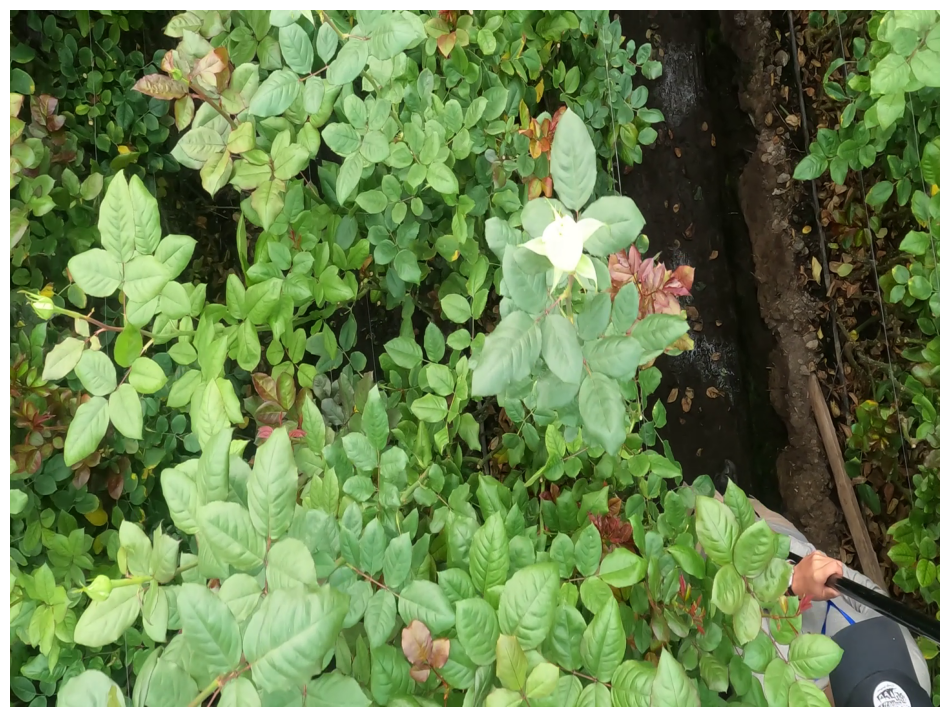

In [11]:
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=390, iterative_seek=True)
frame = next(frame_generator)

sv.plot_image(frame)

### Single-frame inference at 640px

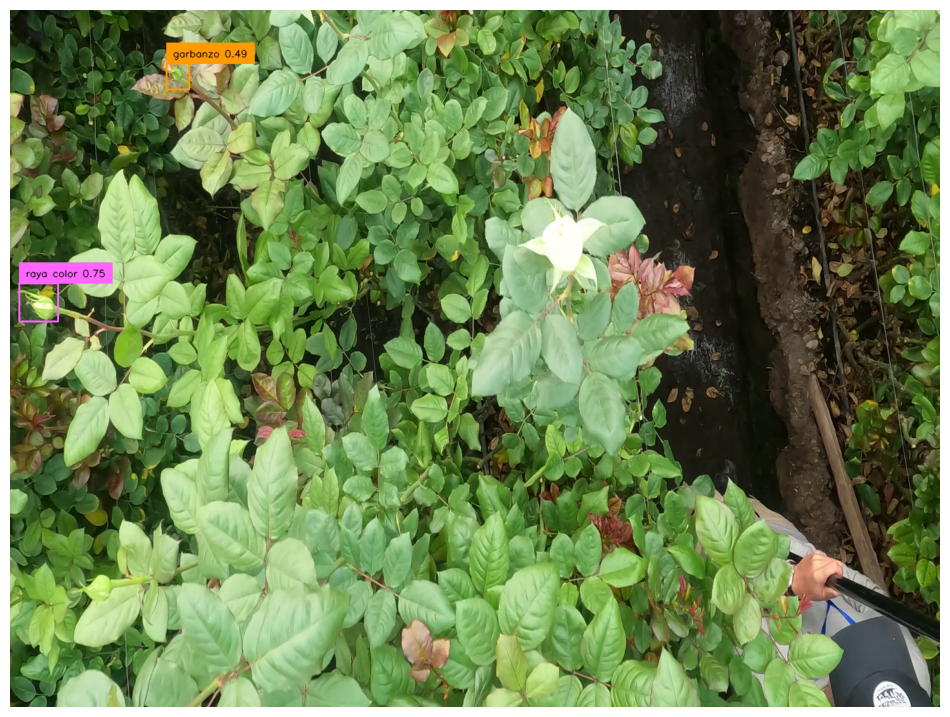

In [12]:
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

result = MODEL(frame, verbose=False)[0]
detections = sv.Detections.from_ultralytics(result)

labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections['class_name'], detections.confidence)
]

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections,
    labels=labels)

sv.plot_image(annotated_frame)

### Single-frame inference at 640px with InferenceSlicer

SupervisionWarnings: `overlap_ratio_wh` in `InferenceSlicer.__init__` is deprecated and will be removed in `supervision-0.27.0`. Please manually set it to `None` and use `overlap_wh` instead.


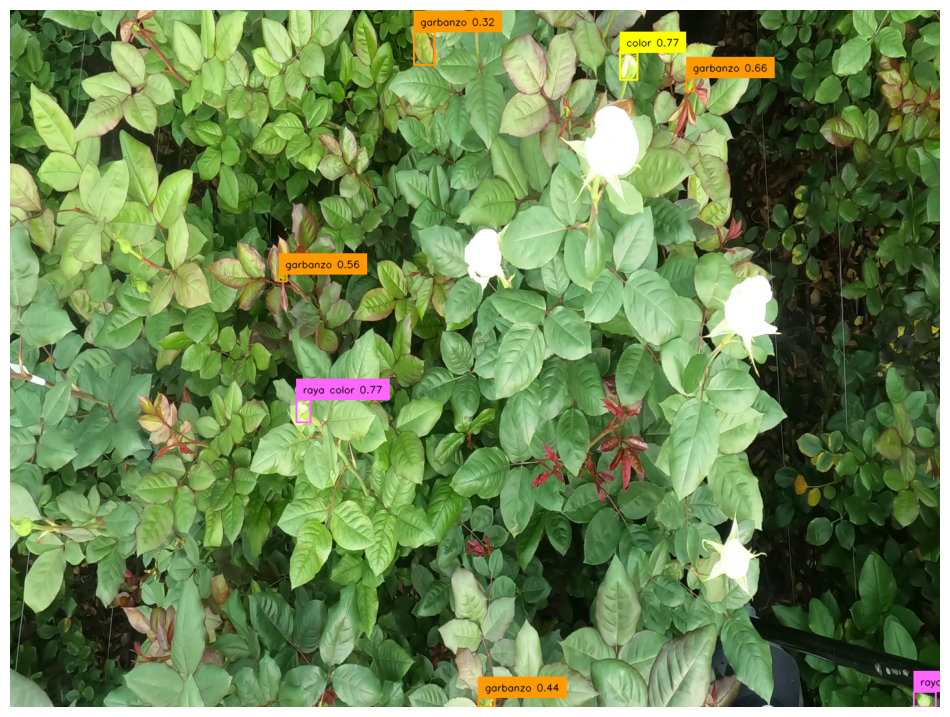

In [ ]:
import numpy as np

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

def callback(image_slice: np.ndarray) -> sv.Detections:
    result = MODEL(image_slice, verbose=False)[0]
    return sv.Detections.from_ultralytics(result)

slicer = sv.InferenceSlicer(callback = callback, slice_wh = (640, 640))
detections = slicer(frame)

labels = [
    f"{class_name} {confidence:.2f}"
    for class_name, confidence
    in zip(detections['class_name'], detections.confidence)
]

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections,
    labels=labels)

sv.plot_image(annotated_frame)

### Full-video inference at 640px with InferenceSlicer and Trackers

In [ ]:
import numpy as np
from trackers import SORTTracker

tracker = SORTTracker()

#src_vid_path = SOURCE_VIDEO_PATH_2
src_vid_path = Path(SOURCE_VIDEO_PATH_2)  # <-- convertir a Path

TARGET_VIDEO_PATH = src_vid_path.parent / f"{src_vid_path.stem}-result{src_vid_path.suffix}"
TARGET_VIDEO_PATH_COMPRESSED = TARGET_VIDEO_PATH.parent / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2, color_lookup=sv.ColorLookup.TRACK)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK, color_lookup=sv.ColorLookup.TRACK)

def slicer_callback(image_slice: np.ndarray) -> sv.Detections:
    result = MODEL(image_slice, conf=0.10, verbose=False)[0]
    return sv.Detections.from_ultralytics(result)

slicer = sv.InferenceSlicer(callback = slicer_callback, slice_wh = (640, 640), iou_threshold=0.3)

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    detections = slicer(frame)
    detections = detections[detections.area < 2000]
    detections = tracker.update(detections)

    if len(detections) == 0:
        return frame

    labels = [
        f"{class_name} {confidence:.2f}"
        for class_name, confidence
        in zip(detections['class_name'], detections.confidence)
    ]

    annotated_frame = frame.copy()
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame,
        detections=detections)
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame,
        detections=detections,
        labels=labels)
    return annotated_frame

sv.process_video(
    source_path=src_vid_path,
    target_path=TARGET_VIDEO_PATH,
    callback=callback
)

SupervisionWarnings: `overlap_ratio_wh` in `InferenceSlicer.__init__` is deprecated and will be removed in `supervision-0.27.0`. Please manually set it to `None` and use `overlap_wh` instead.


KeyboardInterrupt: 

In [40]:
import numpy as np
from pathlib import Path
from trackers import SORTTracker
import supervision as sv
import cv2
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define and verify video path
src_vid_path = Path('/content/drive/MyDrive/Rosas-2025/05-07/redimensionamiento-0.5-6/GX011349.MP4')

# Check if the video file exists
if not src_vid_path.is_file():
    print(f"Directory contents: {[p.name for p in src_vid_path.parent.iterdir()]}")
    raise FileNotFoundError(f"Video file not found at {src_vid_path}")

# Verify video can be opened
video = cv2.VideoCapture(str(src_vid_path))
if not video.isOpened():
    raise Exception(f"Could not open video at {src_vid_path}")
video.release()

# Define output paths
TARGET_VIDEO_PATH = src_vid_path.parent / f"{src_vid_path.stem}-result2{src_vid_path.suffix}"
TARGET_VIDEO_PATH_COMPRESSED = TARGET_VIDEO_PATH.parent / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

# Initialize annotators
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2, color_lookup=sv.ColorLookup.TRACK)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK, color_lookup=sv.ColorLookup.TRACK)

def slicer_callback(image_slice: np.ndarray) -> sv.Detections:
    result = MODEL(image_slice, conf=0.10, verbose=False)[0]
    return sv.Detections.from_ultralytics(result)

# Initialize InferenceSlicer with updated parameters
slicer = sv.InferenceSlicer(
    callback=slicer_callback,
    slice_wh=(640, 640),
    iou_threshold=0.3,
    overlap_ratio_wh=None,  # Avoid deprecation warning
    overlap_wh=(128, 128)   # Adjust overlap as needed
)

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    detections = slicer(frame)
    detections = detections[detections.area < 2000]
    detections = tracker.update(detections)

    if len(detections) == 0:
        return frame

    labels = [
        f"{class_name} {confidence:.2f}"
        for class_name, confidence
        in zip(detections['class_name'], detections.confidence)
    ]

    annotated_frame = frame.copy()
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame,
        detections=detections)
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame,
        detections=detections,
        labels=labels)
    return annotated_frame

# Process the video
sv.process_video(
    source_path=str(src_vid_path),
    target_path=str(TARGET_VIDEO_PATH),
    callback=callback
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
from pathlib import Path
from trackers import SORTTracker
import supervision as sv
import cv2
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define input video path
src_vid_path = Path('/content/drive/MyDrive/Rosas-2025/05-07/redimensionamiento/GX011351.MP4')

# Check if the video file exists
if not src_vid_path.is_file():
    print(f"Directory contents: {[p.name for p in src_vid_path.parent.iterdir()]}")
    raise FileNotFoundError(f"Video file not found at {src_vid_path}")

# Verify video can be opened
video = cv2.VideoCapture(str(src_vid_path))
if not video.isOpened():
    raise Exception(f"Could not open video at {src_vid_path}")
video.release()

# Define output directory (customizable)
output_dir = Path('/content/drive/MyDrive/Rosas-2025/05-07/RESULTADOS')
output_dir.mkdir(parents=True, exist_ok=True)  # Create output directory if it doesn't exist

# Define output paths
TARGET_VIDEO_PATH = output_dir / f"{src_vid_path.stem}-result{src_vid_path.suffix}"
TARGET_VIDEO_PATH_COMPRESSED = output_dir / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

# Initialize tracker and annotators
tracker = SORTTracker()
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2, color_lookup=sv.ColorLookup.TRACK)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK, color_lookup=sv.ColorLookup.TRACK)

def slicer_callback(image_slice: np.ndarray) -> sv.Detections:
    result = MODEL(image_slice, conf=0.10, verbose=False)[0]
    return sv.Detections.from_ultralytics(result)

# Initialize InferenceSlicer with updated parameters
slicer = sv.InferenceSlicer(
    callback=slicer_callback,
    slice_wh=(640, 640),
    iou_threshold=0.3,
    overlap_ratio_wh=None,  # Avoid deprecation warning
    overlap_wh=(128, 128)   # Adjust overlap as needed
)

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    detections = slicer(frame)
    detections = detections[detections.area < 2000]
    detections = tracker.update(detections)

    if len(detections) == 0:
        return frame

    labels = [
        f"{class_name} {confidence:.2f}"
        for class_name, confidence
        in zip(detections['class_name'], detections.confidence)
    ]

    annotated_frame = frame.copy()
    annotated_frame = box_annotator.annotate(
        scene=annotated_frame,
        detections=detections)
    annotated_frame = label_annotator.annotate(
        scene=annotated_frame,
        detections=detections,
        labels=labels)
    return annotated_frame

# Process the video
sv.process_video(
    source_path=str(src_vid_path),
    target_path=str(TARGET_VIDEO_PATH),
    callback=callback
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


KeyboardInterrupt: 

In [ ]:
import numpy as np
from pathlib import Path
import supervision as sv
import cv2
from google.colab import drive
from ultralytics import YOLO
import time

# Mount Google Drive (already mounted, but included for completeness)
drive.mount('/content/drive', force_remount=True)

# Define and verify video path
src_vid_path = Path('/content/drive/MyDrive/Rosas-2025/05-07/redimensionamiento-0.5-6/GX011351.MP4')

# Check if the video file exists
if not src_vid_path.is_file():
    print(f"Directory contents: {[p.name for p in src_vid_path.parent.iterdir()]}")
    raise FileNotFoundError(f"Video file not found at {src_vid_path}")

# Verify video can be opened and print properties
video = cv2.VideoCapture(str(src_vid_path))
if not video.isOpened():
    raise Exception(f"Could not open video at {src_vid_path}")
print(f"Resolution: {int(video.get(cv2.CAP_PROP_FRAME_WIDTH))}x{int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))}")
print(f"Frame count: {int(video.get(cv2.CAP_PROP_FRAME_COUNT))}")
print(f"FPS: {video.get(cv2.CAP_PROP_FPS)}")
video.release()

# Define output directory
output_dir = Path('/content/drive/MyDrive/Rosas-2025/05-07/redimensionamiento-0.5-6/output_videos')
output_dir.mkdir(parents=True, exist_ok=True)

# Define output paths
TARGET_VIDEO_PATH = output_dir / f"{src_vid_path.stem}-result{src_vid_path.suffix}"
TARGET_VIDEO_PATH_COMPRESSED = output_dir / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

# Initialize model and tracker
MODEL = YOLO('/content/drive/MyDrive/Proyecto Rosas - 2/modelos/Y11/mondial-Y11-90.pt').to('cuda')
try:
    from trackers import SORTTracker
    tracker = SORTTracker()  # Try default initialization
except TypeError:
    from supervision.tracker import ByteTrack
    tracker = ByteTrack(track_thresh=0.25, match_thresh=0.8, frame_rate=24)  # Fallback to ByteTrack
COLOR = sv.Color.RED
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2, color_lookup=sv.ColorLookup.TRACK)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK, color_lookup=sv.ColorLookup.TRACK)

def slicer_callback(image_slice: np.ndarray) -> sv.Detections:
    result = MODEL(image_slice, conf=0.3, verbose=False)[0]
    return sv.Detections.from_ultralytics(result)

# Initialize InferenceSlicer with optimized parameters
slicer = sv.InferenceSlicer(
    callback=slicer_callback,
    slice_wh=(512, 512),
    iou_threshold=0.3,
    overlap_ratio_wh=None,
    overlap_wh=(128, 128)
)

def callback(frame: np.ndarray, frame_idx: int) -> np.ndarray:
    start_time = time.time()
    if frame_idx % 2 != 0:  # Process every 2nd frame
        return frame
    detections = slicer(frame)
    detections = detections[detections.area < 10000]
    print(f"Frame {frame_idx}: {len(detections)} detections before tracking")
    detections = tracker.update(detections)
    print(f"Frame {frame_idx}: {len(detections)} detections after tracking, Track IDs: {detections.tracker_id}")
    if len(detections) == 0:
        return frame
    labels = [
        f"{class_name} {confidence:.2f}"
        for class_name, confidence
        in zip(detections['class_name'], detections.confidence)
    ]
    annotated_frame = frame.copy()
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)
    print(f"Frame {frame_idx} processed in {time.time() - start_time:.2f} seconds")
    return annotated_frame

# Process the video
sv.process_video(
    source_path=str(src_vid_path),
    target_path=str(TARGET_VIDEO_PATH),
    callback=callback
)

# Compress the output video
!ffmpeg -i "{TARGET_VIDEO_PATH}" -c:v libx264 -preset fast -crf 23 "{TARGET_VIDEO_PATH_COMPRESSED}"

Mounted at /content/drive
Resolution: 1440x1080
Frame count: 5973
FPS: 23.976023976023978
Frame 0: 2 detections before tracking
Frame 0: 2 detections after tracking, Track IDs: [-1 -1]
Frame 0 processed in 0.52 seconds
Frame 2: 1 detections before tracking
Frame 2: 1 detections after tracking, Track IDs: [-1]
Frame 2 processed in 0.41 seconds
Frame 4: 3 detections before tracking
Frame 4: 3 detections after tracking, Track IDs: [ -1  -1 584]
Frame 4 processed in 0.41 seconds
Frame 6: 1 detections before tracking
Frame 6: 1 detections after tracking, Track IDs: [584]
Frame 6 processed in 0.40 seconds
Frame 8: 2 detections before tracking
Frame 8: 2 detections after tracking, Track IDs: [-1 -1]
Frame 8 processed in 0.41 seconds
Frame 10: 3 detections before tracking
Frame 10: 3 detections after tracking, Track IDs: [-1 -1 -1]
Frame 10 processed in 0.41 seconds
Frame 12: 2 detections before tracking
Frame 12: 2 detections after tracking, Track IDs: [ -1 585]
Frame 12 processed in 0.41 sec

KeyboardInterrupt: 

In [31]:
import numpy as np
from pathlib import Path
from trackers import SORTTracker
import supervision as sv
from ultralytics import YOLO

# -------------------------------
# Configuración
# -------------------------------
MODEL = YOLO(SOURCE_WEIGHTS_PATH)  # Assuming SOURCE_WEIGHTS_PATH is defined
tracker = SORTTracker()

# Ruta del video de entrada
SOURCE_VIDEO_PATH_2 = "/content/drive/MyDrive/Rosas-2025/05-07/redimensionamiento-0.5-6/GX011351.MP4"
src_vid_path = Path(SOURCE_VIDEO_PATH_2)

# Carpeta de resultados
RESULTS_DIR = Path("/content/drive/MyDrive/Rosas-2025/05-07/RESULTADOS-NUEVO-SEGUIDOR")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Rutas de salida
TARGET_VIDEO_PATH = RESULTS_DIR / f"{src_vid_path.stem}-result{src_vid_path.suffix}"
TARGET_VIDEO_PATH_COMPRESSED = RESULTS_DIR / f"{src_vid_path.stem}-compressed{src_vid_path.suffix}"

# -------------------------------
# Colores y clases
# -------------------------------
COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

CLASS_COLORS = {
    "raya color": sv.Color.RED,
    "garbanzo": sv.Color.GREEN,
    "color": sv.Color.BLUE
}

def color_lookup(class_id, class_name) -> sv.Color:
    """
    Función corregida para evitar problemas con supervision
    """
    print(f"[DEBUG] color_lookup called with class_id={class_id}, class_name={class_name}, type={type(class_id)}")

    # CRÍTICO: Asegurar que nunca retornemos None y siempre un Color válido
    # Si class_id es None o no válido, usar un índice por defecto
    if class_id is None:
        print(f"[DEBUG] class_id is None, using default index 0")
        return COLOR.colors[0]  # Usar el primer color como default

    # Intentar convertir a entero de forma segura
    try:
        class_id_int = int(class_id)
        print(f"[DEBUG] Converted class_id to int: {class_id_int}")

        # Asegurar que sea positivo
        if class_id_int < 0:
            print(f"[DEBUG] class_id is negative, using index 0")
            return COLOR.colors[0]

        # Usar el color de la paleta con módulo para evitar overflow
        color_index = class_id_int % len(COLOR.colors)
        selected_color = COLOR.colors[color_index]
        print(f"[DEBUG] Selected color at index {color_index}")
        return selected_color

    except (TypeError, ValueError, AttributeError) as e:
        print(f"[DEBUG] Failed to convert class_id to int: {e}, using default color")
        return COLOR.colors[0]  # Siempre retornar un color válido

# Anotadores SIN color_lookup personalizado para evitar el error
# Usar colores por defecto hasta identificar el problema exacto
box_annotator = sv.BoxAnnotator(thickness=2, color=COLOR)
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK, color=COLOR)

# -------------------------------
# Inference slicer
# -------------------------------
def slicer_callback(image_slice: np.ndarray) -> sv.Detections:
    result = MODEL(image_slice, conf=0.10, verbose=False)[0]
    detections = sv.Detections.from_ultralytics(result)
    print(f"[DEBUG] slicer_callback: class_id={detections.class_id}, class_name={detections.data.get('class_name')}")

    # Asegurar que class_id sea válido
    if detections.class_id is None or len(detections.class_id) == 0:
        detections.class_id = np.zeros(len(detections), dtype=int)
        print(f"[DEBUG] slicer_callback: Fixed class_id to zeros")

    return detections

slicer = sv.InferenceSlicer(
    callback=slicer_callback,
    slice_wh=(640, 640),
    iou_threshold=0.3,
    overlap_ratio_wh=None,
    overlap_wh=(0, 0)
)

# -------------------------------
# Callback para procesar frame
# -------------------------------
def callback(frame: np.ndarray, frame_idx: int) -> np.ndarray:
    detections = slicer(frame)
    print(f"[DEBUG] Frame {frame_idx}: After slicer: class_id={detections.class_id}, class_name={detections.data.get('class_name')}")

    detections = detections[detections.area < 2000]
    print(f"[DEBUG] Frame {frame_idx}: After area filter: class_id={detections.class_id}, class_name={detections.data.get('class_name')}")

    detections = tracker.update(detections)
    print(f"[DEBUG] Frame {frame_idx}: After tracker: class_id={detections.class_id}, class_name={detections.data.get('class_name')}")

    if len(detections) == 0:
        print(f"[DEBUG] Frame {frame_idx}: No detections, returning frame")
        return frame

    # Limpiar y asegurar class_id válido
    if detections.class_id is None:
        print(f"[DEBUG] Frame {frame_idx}: class_id is None, setting to zeros")
        detections.class_id = np.zeros(len(detections), dtype=int)
    else:
        # Convertir a numpy array y limpiar valores inválidos
        class_id_cleaned = []
        for cid in detections.class_id:
            if cid is None:
                class_id_cleaned.append(0)
            else:
                try:
                    class_id_cleaned.append(int(cid))
                except (TypeError, ValueError):
                    class_id_cleaned.append(0)
        detections.class_id = np.array(class_id_cleaned, dtype=int)

    print(f"[DEBUG] Frame {frame_idx}: After class_id fix: class_id={detections.class_id}")

    # Asegurar que class_name esté disponible
    if "class_name" not in detections.data or detections.data["class_name"] is None:
        print(f"[DEBUG] Frame {frame_idx}: class_name missing, setting to 'desconocido'")
        detections.data["class_name"] = np.array(["desconocido"] * len(detections))
    else:
        # Limpiar class_names None
        class_names = detections.data["class_name"]
        class_names_cleaned = [name if name is not None else "desconocido" for name in class_names]
        detections.data["class_name"] = np.array(class_names_cleaned)

    print(f"[DEBUG] Frame {frame_idx}: Final class_name: {detections.data['class_name']}")

    # Crear labels para todas las detecciones
    labels = []
    for i in range(len(detections)):
        class_name = detections.data["class_name"][i]
        confidence = detections.confidence[i] if detections.confidence is not None else 0.0
        labels.append(f"{class_name} {confidence:.2f}")
    print(f"[DEBUG] Frame {frame_idx}: Labels: {labels}")

    annotated_frame = frame.copy()
    # VERIFICACIÓN FINAL: Asegurar que todos los datos sean válidos
    print(f"[DEBUG] Frame {frame_idx}: Final verification before annotation")
    print(f"[DEBUG] class_id shape: {detections.class_id.shape}, dtype: {detections.class_id.dtype}")
    print(f"[DEBUG] class_id values: {detections.class_id}")
    print(f"[DEBUG] class_id contains None: {np.any(detections.class_id == None)}")

    # Verificación adicional: asegurar que no haya None en class_id
    if np.any(detections.class_id == None):
        print(f"[WARNING] Found None values in class_id, fixing...")
        detections.class_id = np.where(detections.class_id == None, 0, detections.class_id)
        detections.class_id = detections.class_id.astype(int)

    print(f"[DEBUG] Frame {frame_idx}: Annotating with class_id={detections.class_id}, class_name={detections.data['class_name']}")

    try:
        annotated_frame = box_annotator.annotate(
            scene=annotated_frame,
            detections=detections
        )
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections,
            labels=labels
        )
    except Exception as e:
        print(f"[ERROR] Frame {frame_idx}: Annotation failed: {str(e)}")
        print(f"[ERROR] Detections info:")
        print(f"  - class_id: {detections.class_id}")
        print(f"  - class_id type: {type(detections.class_id)}")
        print(f"  - class_id dtype: {detections.class_id.dtype}")
        print(f"  - class_name: {detections.data.get('class_name')}")
        print(f"  - xyxy: {detections.xyxy}")
        print(f"  - confidence: {detections.confidence}")
        raise

    return annotated_frame

# -------------------------------
# Procesar video
# -------------------------------
try:
    sv.process_video(
        source_path=src_vid_path,
        target_path=TARGET_VIDEO_PATH,
        callback=callback
    )
    print(f"✅ Video procesado guardado en: {TARGET_VIDEO_PATH}")
except Exception as e:
    print(f"[ERROR] Fallo al procesar el video: {str(e)}")
    import traceback
    traceback.print_exc()

Se truncaron las últimas líneas 5000 del resultado de transmisión.
[DEBUG] slicer_callback: class_id=[], class_name=[]
[DEBUG] slicer_callback: Fixed class_id to zeros
[DEBUG] slicer_callback: class_id=[], class_name=[]
[DEBUG] slicer_callback: Fixed class_id to zeros
[DEBUG] slicer_callback: class_id=[], class_name=[]
[DEBUG] slicer_callback: Fixed class_id to zeros
[DEBUG] Frame 370: After slicer: class_id=[], class_name=None
[DEBUG] Frame 370: After area filter: class_id=[], class_name=None
[DEBUG] Frame 370: After tracker: class_id=[], class_name=None
[DEBUG] Frame 370: No detections, returning frame
[DEBUG] slicer_callback: class_id=[], class_name=[]
[DEBUG] slicer_callback: Fixed class_id to zeros
[DEBUG] slicer_callback: class_id=[], class_name=[]
[DEBUG] slicer_callback: Fixed class_id to zeros
[DEBUG] slicer_callback: class_id=[], class_name=[]
[DEBUG] slicer_callback: Fixed class_id to zeros
[DEBUG] slicer_callback: class_id=[], class_name=[]
[DEBUG] slicer_callback: Fixed cl

KeyboardInterrupt: 

In [39]:
import numpy as np
from pathlib import Path
from trackers import SORTTracker
import supervision as sv
from ultralytics import YOLO
import torch
import cv2
from typing import List
import gc

# -------------------------------
# Configuración GPU
# -------------------------------
# Verificar GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Usando dispositivo: {device}")
if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name()}")
    print(f"[INFO] Memoria GPU disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# -------------------------------
# Configuración
# -------------------------------
MODEL = YOLO(SOURCE_WEIGHTS_PATH)
MODEL.to(device)  # Asegurar que el modelo esté en GPU

# Optimizaciones del modelo
MODEL.model.eval()  # Modo evaluación para mejor rendimiento
if hasattr(MODEL.model, 'half'):
    MODEL.model.half()  # Usar FP16 para mayor velocidad (si es compatible)

tracker = SORTTracker()

# Configuración de procesamiento por lotes
BATCH_SIZE = 4  # Ajusta según tu memoria GPU (4, 8, 16, 32)
SLICE_SIZE = 640  # Tamaño de slice optimizado
CONFIDENCE_THRESHOLD = 0.10
IOU_THRESHOLD = 0.1

# Rutas
SOURCE_VIDEO_PATH_2 = "/content/drive/MyDrive/Rosas-2025/05-07/redimensionamiento-0.5-6/GX011350.MP4"
src_vid_path = Path(SOURCE_VIDEO_PATH_2)

RESULTS_DIR = Path("/content/drive/MyDrive/Rosas-2025/05-07/RESULTADOS-NUEVO-SEGUIDOR")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_VIDEO_PATH = RESULTS_DIR / f"{src_vid_path.stem}-result-iou-0.1-gpu4-v0.5{src_vid_path.suffix}"

# -------------------------------
# Colores
# -------------------------------
COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

box_annotator = sv.BoxAnnotator(thickness=2, color=COLOR)
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK, color=COLOR)

# -------------------------------
# Funciones optimizadas
# -------------------------------
def process_batch_slices(image_slices: List[np.ndarray]) -> List[sv.Detections]:
    """
    Procesa múltiples slices en un solo batch para aprovechar la GPU
    """
    if not image_slices:
        return []

    try:
        # Procesar todo el batch de una vez
        with torch.no_grad():  # Importante para ahorrar memoria
            results = MODEL(image_slices,
                           conf=CONFIDENCE_THRESHOLD,
                           verbose=False,
                           device=device)

        batch_detections = []
        for result in results:
            detections = sv.Detections.from_ultralytics(result)

            # Limpiar class_id
            if detections.class_id is None or len(detections.class_id) == 0:
                detections.class_id = np.zeros(len(detections), dtype=int)

            batch_detections.append(detections)

        return batch_detections

    except Exception as e:
        print(f"[ERROR] Error en batch processing: {e}")
        # Fallback: procesar uno por uno
        batch_detections = []
        for img_slice in image_slices:
            result = MODEL(img_slice, conf=CONFIDENCE_THRESHOLD, verbose=False, device=device)[0]
            detections = sv.Detections.from_ultralytics(result)
            if detections.class_id is None or len(detections.class_id) == 0:
                detections.class_id = np.zeros(len(detections), dtype=int)
            batch_detections.append(detections)

        return batch_detections

def optimized_slicer_callback(image: np.ndarray) -> sv.Detections:
    """
    Slicer optimizado que agrupa slices para procesamiento por lotes
    """
    height, width = image.shape[:2]
    slice_h = slice_w = SLICE_SIZE

    # Calcular slices
    slices_data = []
    slices_images = []

    for y in range(0, height, slice_h):
        for x in range(0, width, slice_w):
            x_end = min(x + slice_w, width)
            y_end = min(y + slice_h, height)

            slice_img = image[y:y_end, x:x_end]
            slices_images.append(slice_img)
            slices_data.append((x, y, x_end, y_end))

    # Procesar slices en batches
    all_detections = []

    for i in range(0, len(slices_images), BATCH_SIZE):
        batch_slices = slices_images[i:i + BATCH_SIZE]
        batch_coords = slices_data[i:i + BATCH_SIZE]

        batch_detections = process_batch_slices(batch_slices)

        # Ajustar coordenadas de cada slice
        for detections, (x_offset, y_offset, _, _) in zip(batch_detections, batch_coords):
            if len(detections) > 0:
                # Ajustar coordenadas al frame completo
                detections.xyxy[:, [0, 2]] += x_offset  # x1, x2
                detections.xyxy[:, [1, 3]] += y_offset  # y1, y2
                all_detections.append(detections)

    # Combinar todas las detecciones
    if all_detections:
        combined_detections = sv.Detections.merge(all_detections)

        # Aplicar NMS global
        if len(combined_detections) > 0:
            # Crear índices para NMS
            boxes = combined_detections.xyxy
            scores = combined_detections.confidence if combined_detections.confidence is not None else np.ones(len(boxes))

            # Convertir a tensor para NMS
            boxes_tensor = torch.from_numpy(boxes).to(device)
            scores_tensor = torch.from_numpy(scores).to(device)

            # Aplicar NMS
            keep_indices = torch.ops.torchvision.nms(boxes_tensor, scores_tensor, IOU_THRESHOLD)
            keep_indices = keep_indices.cpu().numpy()

            # Filtrar detecciones
            combined_detections = combined_detections[keep_indices]

        return combined_detections
    else:
        # Retornar detección vacía
        empty_detections = sv.Detections.empty()
        empty_detections.class_id = np.array([], dtype=int)
        return empty_detections

# -------------------------------
# Callback optimizado
# -------------------------------
def optimized_callback(frame: np.ndarray, frame_idx: int) -> np.ndarray:
    # Limpiar cache de GPU periódicamente
    if frame_idx % 50 == 0:
        torch.cuda.empty_cache()
        gc.collect()
        print(f"[INFO] Frame {frame_idx}: Limpieza de memoria GPU")

    # Procesar frame
    detections = optimized_slicer_callback(frame)

    if len(detections) == 0:
        return frame

    # Filtrar por área
    detections = detections[detections.area < 2000]

    if len(detections) == 0:
        return frame

    # Actualizar tracker
    detections = tracker.update(detections)

    if len(detections) == 0:
        return frame

    # Limpiar datos
    if detections.class_id is None:
        detections.class_id = np.zeros(len(detections), dtype=int)
    else:
        class_id_cleaned = []
        for cid in detections.class_id:
            if cid is None:
                class_id_cleaned.append(0)
            else:
                try:
                    class_id_cleaned.append(int(cid))
                except (TypeError, ValueError):
                    class_id_cleaned.append(0)
        detections.class_id = np.array(class_id_cleaned, dtype=int)

    # Asegurar class_name
    if "class_name" not in detections.data or detections.data["class_name"] is None:
        detections.data["class_name"] = np.array(["desconocido"] * len(detections))
    else:
        class_names = detections.data["class_name"]
        class_names_cleaned = [name if name is not None else "desconocido" for name in class_names]
        detections.data["class_name"] = np.array(class_names_cleaned)

    # Crear labels
    labels = []
    for i in range(len(detections)):
        class_name = detections.data["class_name"][i]
        confidence = detections.confidence[i] if detections.confidence is not None else 0.0
        labels.append(f"{class_name} {confidence:.2f}")

    # Anotar
    annotated_frame = frame.copy()
    try:
        annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
        annotated_frame = label_annotator.annotate(scene=annotated_frame, detections=detections, labels=labels)
    except Exception as e:
        print(f"[ERROR] Frame {frame_idx}: Annotation failed: {str(e)}")
        return frame

    return annotated_frame

# -------------------------------
# Procesamiento principal
# -------------------------------
def main():
    print(f"[INFO] Iniciando procesamiento optimizado para GPU...")
    print(f"[INFO] Batch size: {BATCH_SIZE}")
    print(f"[INFO] Slice size: {SLICE_SIZE}")
    print(f"[INFO] Confidence threshold: {CONFIDENCE_THRESHOLD}")
    print(f"[INFO] IOU threshold: {IOU_THRESHOLD}")

    try:
        # Verificar archivo de entrada
        if not src_vid_path.exists():
            raise FileNotFoundError(f"Video no encontrado: {src_vid_path}")

        # Información del video
        cap = cv2.VideoCapture(str(src_vid_path))
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
        cap.release()

        print(f"[INFO] Video: {total_frames} frames, {fps:.2f} FPS")
        print(f"[INFO] Tiempo estimado con GPU: {total_frames / (fps * 2):.1f} segundos")

        # Procesar video
        sv.process_video(
            source_path=src_vid_path,
            target_path=TARGET_VIDEO_PATH,
            callback=optimized_callback
        )

        print(f"✅ Video procesado guardado en: {TARGET_VIDEO_PATH}")

    except Exception as e:
        print(f"[ERROR] Fallo al procesar el video: {str(e)}")
        import traceback
        traceback.print_exc()
    finally:
        # Limpieza final
        torch.cuda.empty_cache()
        gc.collect()

if __name__ == "__main__":
    main()

[INFO] Usando dispositivo: cuda
[INFO] GPU: NVIDIA L4
[INFO] Memoria GPU disponible: 23.8 GB
[INFO] Iniciando procesamiento optimizado para GPU...
[INFO] Batch size: 4
[INFO] Slice size: 640
[INFO] Confidence threshold: 0.1
[INFO] IOU threshold: 0.1
[INFO] Video: 5973 frames, 23.98 FPS
[INFO] Tiempo estimado con GPU: 124.6 segundos
[INFO] Frame 0: Limpieza de memoria GPU
[INFO] Frame 50: Limpieza de memoria GPU
[INFO] Frame 100: Limpieza de memoria GPU
[INFO] Frame 150: Limpieza de memoria GPU
[INFO] Frame 200: Limpieza de memoria GPU
[INFO] Frame 250: Limpieza de memoria GPU
[INFO] Frame 300: Limpieza de memoria GPU
[INFO] Frame 350: Limpieza de memoria GPU
[INFO] Frame 400: Limpieza de memoria GPU
[INFO] Frame 450: Limpieza de memoria GPU
[INFO] Frame 500: Limpieza de memoria GPU
[INFO] Frame 550: Limpieza de memoria GPU
[INFO] Frame 600: Limpieza de memoria GPU
[INFO] Frame 650: Limpieza de memoria GPU
[INFO] Frame 700: Limpieza de memoria GPU
[INFO] Frame 750: Limpieza de memoria G

In [ ]:
!ffmpeg -y -i "{TARGET_VIDEO_PATH}" -vcodec libx264 -crf 28 "{TARGET_VIDEO_PATH_COMPRESSED}"

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
from IPython.display import HTML
from base64 import b64encode

def display_video(path, width=1280):
    video_file = open(path, "rb").read()
    video_url = "data:video/mp4;base64," + b64encode(video_file).decode()
    return HTML(f"""
    <video width={width} controls>
        <source src="{video_url}" type="video/mp4">
    </video>
    """)

display_video(TARGET_VIDEO_PATH_COMPRESSED)

Output hidden; open in https://colab.research.google.com to view.